# 🔥 클래스별 Threshold 분리 + 연속 프레임 필터 효과 검증 (19-2)

## 목적
- 기존 19-1은 **단일 Threshold(0.10)**로 모든 클래스를 동일하게 처리
- 19-2는 **클래스별 Threshold 분리**: fire는 낮게(미탐 방지), smoke는 높게(오탐 감소)
- **3단계 비교**: 단일 conf → 클래스별 Threshold → 연속 프레임 필터

## 테스트 환경
| 항목 | 값 |
|------|-----|
| 모델 | YOLOv8n (Fine-tuned) |
| 환경 | CPU |
| YOLO 추론 Threshold | 0.10 (일단 다 받기) |
| fire 후처리 Threshold | 0.10 |
| smoke 후처리 Threshold | 0.25 |
| 연속 프레임 기준 | 10프레임 |
| 테스트 영상 | 2.mp4 |

## 3단계 비교
| 단계 | 설명 |
|------|------|
| 1단계 | 단일 conf=0.10, 필터 없음 (raw) |
| 2단계 | 클래스별 Threshold 후처리 적용 |
| 3단계 | 연속 10프레임 필터 적용 |

## 산출물
| 산출물 | 설명 |
|--------|------|
| `원본/` 폴더 | 탐지 이벤트 시작 시점의 원본 이미지 |
| `bbox/` 폴더 | 탐지 이벤트 시작 시점의 바운딩박스 이미지 |
| `after_원본/` 폴더 | After 알람 시점의 원본 이미지 |
| `after_bbox/` 폴더 | After 알람 시점의 bbox 이미지 |
| `before_detections.csv` | Before 전체 탐지 기록 |
| `after_alarms.csv` | After 알람 기록 |
| `filter_summary.json` | 3단계 비교 요약 |
| `detection_preview.png` | Before 이미지 미리보기 |
| `after_detection_preview.png` | After 이미지 미리보기 |
| `class_distribution.png` | 클래스별 파이 차트 |
| `temporal_filter_timeline.png` | 4행 타임라인 |
| `three_stage_comparison.png` | 3단계 비교 막대 그래프 |
| `frame_threshold_comparison.png` | 프레임 수별 비교 |

In [1]:
# =============================================================================
# 셀 1: 라이브러리 import
# =============================================================================

from ultralytics import YOLO          # YOLOv8 모델 로드 및 추론
import cv2                            # OpenCV — 영상/이미지 처리
from pathlib import Path              # 파일 경로 처리
import numpy as np                    # 숫자 계산 (평균 등)
import time                           # 시간 측정
import json                           # JSON 파일 저장
import csv                            # CSV 파일 저장
import matplotlib.pyplot as plt       # 그래프 시각화
import matplotlib                     # matplotlib 설정

# 한글 폰트 설정 (그래프에서 한글 깨짐 방지)
matplotlib.rcParams["font.family"] = "Malgun Gothic"   # 윈도우 한글 폰트
matplotlib.rcParams["axes.unicode_minus"] = False       # 마이너스 깨짐 방지

print("✅ 라이브러리 로드 완료!")                        # 확인 메시지

✅ 라이브러리 로드 완료!


In [2]:
# =============================================================================
# 셀 2: 설정값
# =============================================================================

# 프로젝트 루트 경로
PROJECT_ROOT = Path(r"N:\개인\이수빈\3.13_Mini_Project")

# 모델 경로 (Fine-tuned YOLOv8n)
MODEL_PATH = PROJECT_ROOT / "results" / "yolov8n_tuned" / "weights" / "best.pt"

# 테스트 영상 경로
VIDEO_PATH = PROJECT_ROOT / "DATASET" / "테스트영상" / "2.mp4"

# ============ 클래스별 Threshold 설정 (여기서 조절) ============
CONF_THRESHOLD = 0.10          # YOLO 추론 시 최소 conf (낮게 → 일단 다 받기)
FIRE_THRESHOLD = 0.10          # fire 후처리 기준 (미탐 방지 → 낮게 유지)
SMOKE_THRESHOLD = 0.25         # smoke 후처리 기준 (오탐 감소 → 높게)
# ==============================================================

# ★★★ 연속 프레임 기준 ★★★
CONSECUTIVE_FRAMES = 10        # 연속 N프레임 이상 탐지 시 알람

# GPU/CPU 설정
DEVICE = "cpu"                 # CPU 환경 (따옴표 포함 문자열!)

# ★ 이미지 저장 경로
SAVE_ROOT = PROJECT_ROOT / "results" / "class_threshold_test"  # 결과 루트
SAVE_ORIG = SAVE_ROOT / "원본"         # 원본 이미지 저장 폴더
SAVE_BBOX = SAVE_ROOT / "bbox"         # bbox 이미지 저장 폴더

# 폴더 자동 생성
SAVE_ROOT.mkdir(parents=True, exist_ok=True)   # 상위 폴더 생성
SAVE_ORIG.mkdir(parents=True, exist_ok=True)   # 원본 폴더 생성
SAVE_BBOX.mkdir(parents=True, exist_ok=True)   # bbox 폴더 생성

# 이미지 저장 옵션
SAVE_EVERY_EVENT = True        # True = 이벤트 시작 시점만 저장

# 설정 확인 출력
print(f"📁 프로젝트 경로: {PROJECT_ROOT}")
print(f"🧠 모델 경로: {MODEL_PATH}")
print(f"🎬 영상 경로: {VIDEO_PATH}")
print(f"🎯 YOLO 추론 Threshold: {CONF_THRESHOLD}")
print(f"🔥 fire 후처리 Threshold: {FIRE_THRESHOLD}")
print(f"💨 smoke 후처리 Threshold: {SMOKE_THRESHOLD}")
print(f"🔢 연속 프레임 기준: {CONSECUTIVE_FRAMES}")
print(f"🖥️ 장치: {DEVICE}")
print(f"📸 이미지 저장 경로: {SAVE_ROOT}")

📁 프로젝트 경로: N:\개인\이수빈\3.13_Mini_Project
🧠 모델 경로: N:\개인\이수빈\3.13_Mini_Project\results\yolov8n_tuned\weights\best.pt
🎬 영상 경로: N:\개인\이수빈\3.13_Mini_Project\DATASET\테스트영상\2.mp4
🎯 YOLO 추론 Threshold: 0.1
🔥 fire 후처리 Threshold: 0.1
💨 smoke 후처리 Threshold: 0.25
🔢 연속 프레임 기준: 10
🖥️ 장치: cpu
📸 이미지 저장 경로: N:\개인\이수빈\3.13_Mini_Project\results\class_threshold_test


In [4]:
# =============================================================================
# 셀 3: 모델 로드 + 클래스 확인
# =============================================================================

print("📦 모델 로드 중...")                       # 로딩 시작 알림
model = YOLO(str(MODEL_PATH))                       # YOLO 모델 로드
print(f"✅ 모델 로드 완료: {MODEL_PATH.name}")      # 로드 완료 알림

# ★ 모델의 클래스 목록 확인 (smoke, fire 등)
class_names = model.names                            # {0: "fire", 1: "smoke"} 같은 딕셔너리
print(f"📋 모델 클래스 목록:")                    # 클래스 목록 제목
for idx, name in class_names.items():                # 클래스 번호와 이름 출력
    print(f"   {idx}: {name}")                       # 예: 0: fire, 1: smoke

# ★ 클래스별 Threshold 매핑 확인
CLASS_THRESHOLDS = {}                                # 클래스 번호 → Threshold 딕셔너리
for idx, name in class_names.items():                # 모델의 모든 클래스 순회
    if name == "fire":                               # fire 클래스면
        CLASS_THRESHOLDS[idx] = FIRE_THRESHOLD       # fire Threshold 적용
    elif name == "smoke":                            # smoke 클래스면
        CLASS_THRESHOLDS[idx] = SMOKE_THRESHOLD      # smoke Threshold 적용
    else:                                            # 그 외 클래스 (혹시 있으면)
        CLASS_THRESHOLDS[idx] = CONF_THRESHOLD       # 기본 Threshold 적용

print(f"🎯 클래스별 Threshold 매핑:")             # 매핑 확인 제목
for idx, th in CLASS_THRESHOLDS.items():             # 매핑 출력
    print(f"   {idx}: {class_names[idx]} → {th}")   # 예: 0: fire → 0.10


📦 모델 로드 중...
✅ 모델 로드 완료: best.pt
📋 모델 클래스 목록:
   0: fire
   1: smoke
🎯 클래스별 Threshold 매핑:
   0: fire → 0.1
   1: smoke → 0.25


In [5]:
# =============================================================================
# 셀 4: 영상 정보 확인
# =============================================================================

cap = cv2.VideoCapture(str(VIDEO_PATH))             # 영상 파일 열기

if not cap.isOpened():                               # 열기 실패 시
    print(f"❌ 영상을 열 수 없습니다: {VIDEO_PATH}") # 에러 메시지
else:                                                # 열기 성공 시
    fps = cap.get(cv2.CAP_PROP_FPS)                  # FPS (초당 프레임 수)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))  # 총 프레임 수
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))   # 영상 가로 해상도
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT)) # 영상 세로 해상도
    duration = total_frames / fps if fps > 0 else 0  # 영상 길이 (초)

    print(f"🎬 영상 정보:")                          # 제목
    print(f"   파일: {VIDEO_PATH.name}")             # 파일명
    print(f"   해상도: {width} x {height}")          # 해상도
    print(f"   FPS: {fps:.1f}")                      # FPS
    print(f"   총 프레임: {total_frames:,}")         # 총 프레임 수 (천단위 콤마)
    print(f"   영상 길이: {duration:.1f}초 ({duration/60:.1f}분)")  # 길이

    # 예상 소요 시간 (CPU 기준 약 프레임당 0.1~0.3초)
    est_min = total_frames * 0.1 / 60               # 빠른 경우 (초)
    est_max = total_frames * 0.3 / 60               # 느린 경우 (초)
    print(f"   ⏱️ 예상 소요: {est_min:.0f}~{est_max:.0f}분 (CPU 기준)")

    cap.release()                                    # 영상 파일 닫기 (셀 5에서 다시 엶)


🎬 영상 정보:
   파일: 2.mp4
   해상도: 1920 x 1080
   FPS: 30.0
   총 프레임: 37,434
   영상 길이: 1247.8초 (20.8분)
   ⏱️ 예상 소요: 62~187분 (CPU 기준)


## 🔵 Before 테스트 — 클래스별 Threshold 후처리 적용

**19-1과의 차이점:**
- 19-1: `model.predict(conf=0.10)` → 나온 결과 그대로 사용
- 19-2: `model.predict(conf=0.10)` → **클래스별 후처리 필터링** 추가
  - fire (class 0): confidence ≥ 0.10 → 유지
  - smoke (class 1): confidence ≥ 0.25 → 유지 (그 이하는 제거)

**추가 추적 변수:**
- `raw_frame_results`: 후처리 전 탐지 여부 (conf=0.10 기준)
- `before_frame_results`: 후처리 후 탐지 여부 (클래스별 Threshold 적용)
- 이 두 리스트를 비교하면 클래스별 Threshold의 효과를 볼 수 있음


In [6]:
# =============================================================================
# 셀 5: Before 테스트 — 클래스별 Threshold 후처리 적용
# =============================================================================

print("=" * 60)                                     # 구분선
print("🔵 Before 테스트 시작 (클래스별 Threshold 후처리)")  # 시작 알림
print(f"   🔥 fire Threshold: {FIRE_THRESHOLD}")     # fire 기준 출력
print(f"   💨 smoke Threshold: {SMOKE_THRESHOLD}")   # smoke 기준 출력
print("=" * 60)                                     # 구분선

cap = cv2.VideoCapture(str(VIDEO_PATH))             # 영상 열기
fps = cap.get(cv2.CAP_PROP_FPS)                     # FPS
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))  # 총 프레임

# ── 결과 저장용 리스트 ──────────────────────────────────────────────
before_detections = []       # 탐지 정보 리스트 (프레임, 시간, 클래스 등)
before_frame_results = []    # ★ 후처리 후 탐지 여부 [True, False, ...]
before_frame_classes = []    # ★ 후처리 후 탐지된 클래스 목록
raw_frame_results = []       # ★ 후처리 전 탐지 여부 (3단계 비교용)

# ── 이미지 저장 관련 ────────────────────────────────────────────────
in_event = False             # 현재 탐지 이벤트 진행 중인지
saved_count = 0              # 저장한 이미지 수

# ── 통계 변수 ──────────────────────────────────────────────────────
total_fire = 0               # fire 탐지 프레임 수 (후처리 후)
total_smoke = 0              # smoke 탐지 프레임 수 (후처리 후)
total_both = 0               # fire+smoke 동시 탐지 프레임 수
raw_detect_count = 0         # 후처리 전 탐지 프레임 수 (3단계 비교용)
filtered_detect_count = 0    # 후처리 후 탐지 프레임 수 (3단계 비교용)
filtered_out_smoke = 0       # smoke Threshold로 제거된 박스 수

# ── bbox 색상 정의 ─────────────────────────────────────────────────
COLOR_MAP = {                                       # 클래스명 → BGR 색상
    "fire": (0, 0, 255),                            # 빨간색 (BGR)
    "smoke": (128, 128, 128),                       # 회색 (BGR)
}
DEFAULT_COLOR = (0, 255, 0)                         # 기본 색상 (초록)

frame_idx = 0                # 프레임 번호
start_time = time.time()     # 시작 시각

while True:
    ret, frame = cap.read()                         # 프레임 읽기
    if not ret:                                     # 영상 끝
        break                                       # 루프 종료

    # ── YOLO 추론 (conf=0.10으로 일단 다 받기) ──────────────────────
    results = model.predict(                        # 모델 예측
        frame,                                      # 입력 이미지
        conf=CONF_THRESHOLD,                        # 0.10 (낮게 다 받기)
        imgsz=640,                                  # 입력 크기 고정
        device=DEVICE,                              # CPU
        verbose=False                               # 로그 끄기
    )

    # ── 추론 결과 가져오기 ──────────────────────────────────────────
    boxes = results[0].boxes                        # 바운딩박스 객체
    raw_detected = len(boxes) > 0                   # 후처리 전 탐지 여부
    raw_frame_results.append(raw_detected)          # ★ 후처리 전 결과 저장
    if raw_detected:                                # 후처리 전 탐지 있으면
        raw_detect_count += 1                       # 카운터 증가

    # ── ★★★ 클래스별 Threshold 후처리 ★★★ ──────────────────────────
    frame_classes = []                              # 후처리 후 클래스 목록
    class_details = []                              # 상세 정보 (저장용)
    kept_boxes = []                                 # 후처리 통과한 bbox 정보

    if raw_detected:                                # 탐지가 있으면
        for box in boxes:                           # 각 바운딩박스마다
            cls_id = int(box.cls[0])                # 클래스 번호 (0 or 1)
            cls_name = class_names[cls_id]          # 클래스 이름
            conf = float(box.conf[0])               # 신뢰도
            threshold = CLASS_THRESHOLDS[cls_id]    # 해당 클래스의 Threshold

            # ★ 클래스별 Threshold 비교
            if conf >= threshold:                   # Threshold 이상이면 유지
                frame_classes.append(cls_name)      # 클래스 추가
                class_details.append({              # 상세 정보 저장
                    "class": cls_name,              # 클래스명
                    "confidence": round(conf, 4),   # 신뢰도
                    "bbox": box.xyxy[0].tolist()    # 좌표
                })
                kept_boxes.append({                 # bbox 그리기용 정보
                    "x1y1x2y2": box.xyxy[0].cpu().numpy().astype(int),
                    "cls_name": cls_name,           # 클래스명
                    "conf": conf                    # 신뢰도
                })
            else:                                   # Threshold 미만이면 제거
                if cls_name == "smoke":             # smoke가 제거된 경우
                    filtered_out_smoke += 1         # 제거 카운터 증가

    # ── 후처리 후 탐지 여부 판정 ────────────────────────────────────
    detected = len(frame_classes) > 0               # 후처리 후 탐지 여부
    before_frame_results.append(detected)           # ★ 후처리 후 결과 저장
    before_frame_classes.append(frame_classes)      # 클래스 목록 저장
    if detected:                                    # 후처리 후 탐지 있으면
        filtered_detect_count += 1                  # 카운터 증가

    # ── 통계 업데이트 ───────────────────────────────────────────────
    if detected:                                    # 후처리 후 탐지 있으면
        unique_classes = set(frame_classes)         # 중복 제거
        has_fire = "fire" in unique_classes         # fire 포함 여부
        has_smoke = "smoke" in unique_classes       # smoke 포함 여부
        if has_fire:                                # fire 있으면
            total_fire += 1                         # fire 카운트
        if has_smoke:                               # smoke 있으면
            total_smoke += 1                        # smoke 카운트
        if has_fire and has_smoke:                  # 둘 다 있으면
            total_both += 1                         # 동시 탐지 카운트

    # ── 이미지 저장 (탐지 이벤트 시작 시점만) ───────────────────────
    if detected and not in_event:                   # 새로운 탐지 이벤트 시작!
        in_event = True                             # 이벤트 진행 중 표시
        saved_count += 1                            # 저장 카운터 증가

        # 시간 정보
        time_sec = frame_idx / fps if fps > 0 else 0  # 초 단위 시간
        minutes = int(time_sec // 60)               # 분
        seconds = time_sec % 60                     # 초

        # 파일명: 이벤트번호_프레임번호_시간_클래스
        cls_str = "+".join(sorted(set(frame_classes)))  # 예: "fire+smoke"
        fname = f"evt{saved_count:03d}_f{frame_idx:06d}_{minutes:02d}m{seconds:04.1f}s_{cls_str}"

        # 원본 이미지 저장
        orig_path = SAVE_ORIG / f"{fname}.jpg"      # 원본 경로
        cv2.imwrite(str(orig_path), frame)          # 원본 저장

        # ★ bbox 이미지 — OpenCV로 직접 그리기 (후처리 통과한 것만)
        bbox_frame = frame.copy()                   # 원본 복사
        for kb in kept_boxes:                       # 후처리 통과한 bbox만 순회
            x1, y1, x2, y2 = kb["x1y1x2y2"]        # 좌표 꺼내기
            color = COLOR_MAP.get(kb["cls_name"], DEFAULT_COLOR)  # 색상
            cv2.rectangle(bbox_frame, (x1, y1), (x2, y2), color, 2)  # 사각형
            label = f'{kb["cls_name"]} {kb["conf"]:.2f}'  # 라벨 텍스트
            (tw, th), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.6, 1)
            cv2.rectangle(bbox_frame, (x1, y1-th-8), (x1+tw+4, y1), color, -1)  # 배경
            cv2.putText(bbox_frame, label, (x1+2, y1-4),  # 텍스트
                        cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255,255,255), 1, cv2.LINE_AA)

        bbox_path = SAVE_BBOX / f"{fname}.jpg"      # bbox 경로
        cv2.imwrite(str(bbox_path), bbox_frame)     # bbox 저장

    elif not detected:                              # 탐지 안 되면
        in_event = False                            # 이벤트 종료

    # ── 탐지 기록 저장 ──────────────────────────────────────────────
    if detected:                                    # 후처리 후 탐지 있으면
        time_sec = frame_idx / fps if fps > 0 else 0
        before_detections.append({                  # 탐지 기록 추가
            "frame": frame_idx,                     # 프레임 번호
            "time_sec": round(time_sec, 2),         # 시간(초)
            "num_boxes": len(kept_boxes),           # 박스 수 (후처리 후)
            "classes": frame_classes.copy(),        # 탐지된 클래스 목록
            "class_str": "+".join(sorted(set(frame_classes))),  # 문자열
            "details": class_details.copy()         # 상세 정보
        })

    frame_idx += 1                                  # 프레임 번호 증가

    # 진행률 (500프레임마다)
    if frame_idx % 500 == 0:                        # 500프레임마다
        elapsed = time.time() - start_time          # 경과 시간
        pct = frame_idx / total_frames * 100        # 진행률 (%)
        fps_proc = frame_idx / elapsed if elapsed > 0 else 0  # 처리 FPS
        remain = (total_frames - frame_idx) / fps_proc / 60 if fps_proc > 0 else 0
        print(f"   [{pct:5.1f}%] {frame_idx:,}/{total_frames:,} | "
              f"{fps_proc:.1f} fps | 잔여 {remain:.1f}분 | "
              f"탐지(raw): {raw_detect_count} → 탐지(filtered): {filtered_detect_count}")

cap.release()                                       # 영상 파일 닫기
elapsed = time.time() - start_time                  # 총 소요 시간

# ── Before 결과 CSV 저장 ───────────────────────────────────────────
csv_path = SAVE_ROOT / "before_detections.csv"      # CSV 경로
with open(csv_path, "w", newline="", encoding="utf-8-sig") as f:
    writer = csv.writer(f)                          # CSV writer
    writer.writerow(["프레임", "시간(초)", "박스수", "클래스", "상세"])  # 헤더
    for det in before_detections:                   # 탐지 기록 순회
        writer.writerow([                           # 한 행 쓰기
            det["frame"],                           # 프레임 번호
            det["time_sec"],                        # 시간
            det["num_boxes"],                       # 박스 수
            det["class_str"],                       # 클래스 문자열
            json.dumps(det["details"], ensure_ascii=False)  # 상세 JSON
        ])

# ── 결과 출력 ──────────────────────────────────────────────────────
print()
print("=" * 60)                                     # 구분선
print(f"📊 Before 테스트 완료! ({elapsed:.1f}초 소요)")  # 완료 메시지
print(f"   총 프레임: {frame_idx:,}")                # 총 프레임
print(f"   후처리 전 탐지 프레임 (raw): {raw_detect_count:,}")  # raw
print(f"   후처리 후 탐지 프레임 (filtered): {filtered_detect_count:,}")  # filtered
print(f"   → smoke Threshold로 제거된 박스: {filtered_out_smoke:,}개")
print(f"   🔥 fire 프레임: {total_fire:,}")          # fire 수
print(f"   💨 smoke 프레임: {total_smoke:,}")        # smoke 수
print(f"   📸 저장된 이미지: {saved_count}세트")     # 이미지 수
print(f"   📁 CSV: {csv_path}")                     # CSV 경로


🔵 Before 테스트 시작 (클래스별 Threshold 후처리)
   🔥 fire Threshold: 0.1
   💨 smoke Threshold: 0.25
   [  1.3%] 500/37,434 | 17.0 fps | 잔여 36.3분 | 탐지(raw): 0 → 탐지(filtered): 0
   [  2.7%] 1,000/37,434 | 14.2 fps | 잔여 42.6분 | 탐지(raw): 20 → 탐지(filtered): 0
   [  4.0%] 1,500/37,434 | 12.6 fps | 잔여 47.7분 | 탐지(raw): 24 → 탐지(filtered): 4
   [  5.3%] 2,000/37,434 | 12.1 fps | 잔여 48.7분 | 탐지(raw): 26 → 탐지(filtered): 4
   [  6.7%] 2,500/37,434 | 12.1 fps | 잔여 48.0분 | 탐지(raw): 35 → 탐지(filtered): 8
   [  8.0%] 3,000/37,434 | 11.6 fps | 잔여 49.4분 | 탐지(raw): 41 → 탐지(filtered): 14
   [  9.3%] 3,500/37,434 | 11.4 fps | 잔여 49.7분 | 탐지(raw): 53 → 탐지(filtered): 24
   [ 10.7%] 4,000/37,434 | 11.5 fps | 잔여 48.3분 | 탐지(raw): 63 → 탐지(filtered): 34
   [ 12.0%] 4,500/37,434 | 11.5 fps | 잔여 47.8분 | 탐지(raw): 85 → 탐지(filtered): 56
   [ 13.4%] 5,000/37,434 | 11.2 fps | 잔여 48.2분 | 탐지(raw): 85 → 탐지(filtered): 56
   [ 14.7%] 5,500/37,434 | 10.9 fps | 잔여 48.9분 | 탐지(raw): 95 → 탐지(filtered): 64
   [ 16.0%] 6,000/37,434 | 10.7 fps | 잔

📸 저장된 이미지: 원본 47장, bbox 47장


C:\Users\User\AppData\Local\Temp\ipykernel_10896\1473266219.py:38: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) Malgun Gothic.
  plt.tight_layout()                               # 레이아웃 자동 조정
C:\Users\User\AppData\Local\Temp\ipykernel_10896\1473266219.py:39: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) Malgun Gothic.
  plt.savefig(str(SAVE_ROOT / "detection_preview.png"),
c:\Users\User\.conda\envs\DL\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


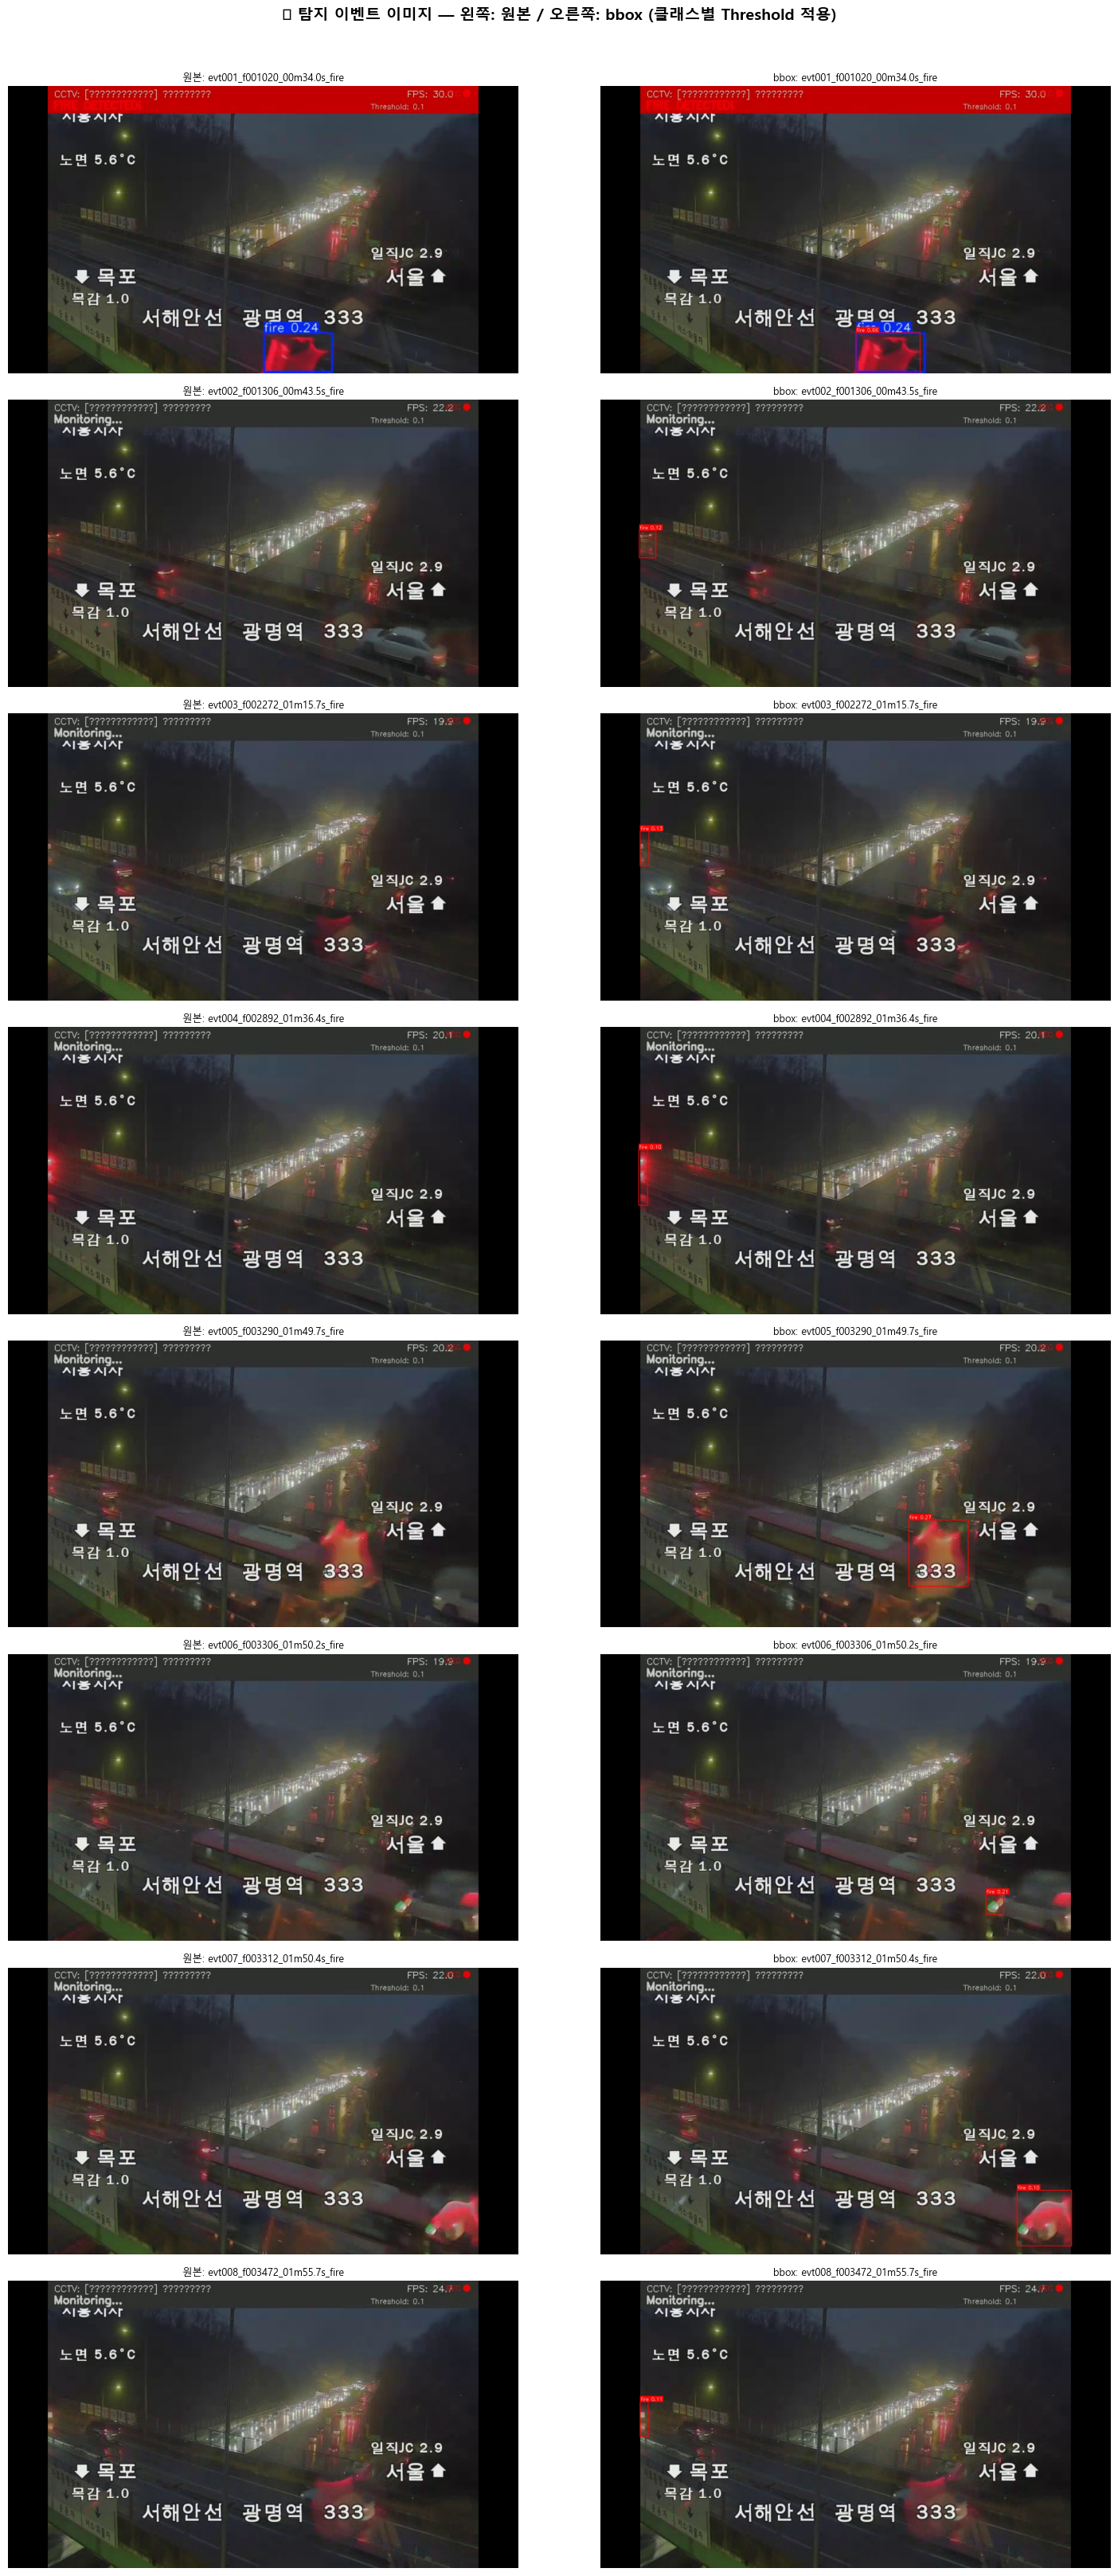


💾 미리보기 저장: N:\개인\이수빈\3.13_Mini_Project\results\class_threshold_test\detection_preview.png


In [7]:
# =============================================================================
# 셀 6: 저장된 이미지 미리보기 (처음 8개)
# =============================================================================

# 저장된 bbox 이미지 목록 가져오기
bbox_images = sorted(SAVE_BBOX.glob("*.jpg"))       # bbox 폴더의 모든 jpg
orig_images = sorted(SAVE_ORIG.glob("*.jpg"))       # 원본 폴더의 모든 jpg

print(f"📸 저장된 이미지: 원본 {len(orig_images)}장, bbox {len(bbox_images)}장")

# 미리보기 (최대 8개, 원본+bbox 쌍으로)
show_count = min(8, len(bbox_images))               # 최대 8개까지

if show_count > 0:                                   # 이미지가 있으면
    fig, axes = plt.subplots(show_count, 2,          # N행 2열
                             figsize=(16, 4 * show_count))  # 크기

    if show_count == 1:                              # 1개일 때 axes 형태 맞추기
        axes = [axes]

    for i in range(show_count):                      # 각 이미지마다
        # 원본 이미지
        orig_img = cv2.imread(str(orig_images[i]))   # 이미지 읽기
        orig_img = cv2.cvtColor(orig_img, cv2.COLOR_BGR2RGB)  # BGR→RGB 변환
        axes[i][0].imshow(orig_img)                  # 원본 표시
        axes[i][0].set_title(f"원본: {orig_images[i].stem}", fontsize=9)
        axes[i][0].axis("off")                      # 축 숨기기

        # bbox 이미지
        bbox_img = cv2.imread(str(bbox_images[i]))   # 이미지 읽기
        bbox_img = cv2.cvtColor(bbox_img, cv2.COLOR_BGR2RGB)  # BGR→RGB 변환
        axes[i][1].imshow(bbox_img)                  # bbox 표시
        axes[i][1].set_title(f"bbox: {bbox_images[i].stem}", fontsize=9)
        axes[i][1].axis("off")                      # 축 숨기기

    plt.suptitle("🔍 탐지 이벤트 이미지 — 왼쪽: 원본 / 오른쪽: bbox (클래스별 Threshold 적용)",
                 fontsize=14, fontweight="bold", y=1.01)
    plt.tight_layout()                               # 레이아웃 자동 조정
    plt.savefig(str(SAVE_ROOT / "detection_preview.png"),
                dpi=120, bbox_inches="tight")         # 파일 저장
    plt.show()                                       # 화면 표시
    print(f"\n💾 미리보기 저장: {SAVE_ROOT / 'detection_preview.png'}")
else:                                                # 이미지 없으면
    print("ℹ️ 저장된 이미지가 없습니다")

🔥💨 클래스별 탐지 분석

📊 전체 탐지 프레임 (클래스별 Threshold 적용 후): 148개
   🔥 fire 포함: 144개 (97.3%)
   💨 smoke 포함: 4개 (2.7%)

📊 연속 10프레임 필터 적용 시 (클래스별):
   🔥 fire 알람: 2회
      프레임   4381 |   146.03초
      프레임   4465 |   148.83초
   💨 smoke 알람: 0회


C:\Users\User\AppData\Local\Temp\ipykernel_10896\1253967700.py:124: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) Malgun Gothic.
  plt.tight_layout()                                  # 레이아웃 자동 조정
C:\Users\User\AppData\Local\Temp\ipykernel_10896\1253967700.py:124: UserWarning: Glyph 128168 (\N{DASH SYMBOL}) missing from font(s) Malgun Gothic.
  plt.tight_layout()                                  # 레이아웃 자동 조정
C:\Users\User\AppData\Local\Temp\ipykernel_10896\1253967700.py:125: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) Malgun Gothic.
  plt.savefig(str(SAVE_ROOT / "class_distribution.png"), dpi=150, bbox_inches="tight")
C:\Users\User\AppData\Local\Temp\ipykernel_10896\1253967700.py:125: UserWarning: Glyph 128168 (\N{DASH SYMBOL}) missing from font(s) Malgun Gothic.
  plt.savefig(str(SAVE_ROOT / "class_distribution.png"), dpi=150, bbox_inches="tight")
c:\Users\User\.conda\envs\DL\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128293 (\N{FIRE}

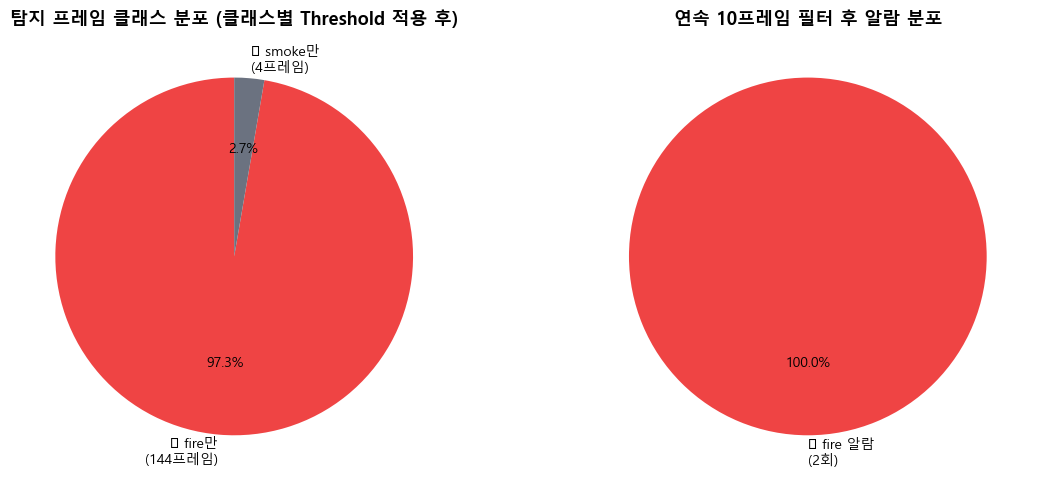


💾 그래프 저장: N:\개인\이수빈\3.13_Mini_Project\results\class_threshold_test\class_distribution.png


In [8]:
# =============================================================================
# 셀 7: 클래스별 상세 분석 — smoke vs fire
# =============================================================================

print("=" * 60)
print("🔥💨 클래스별 탐지 분석")
print("=" * 60)

# 클래스별 탐지 프레임 분리
fire_frames = []             # fire가 탐지된 프레임 목록
smoke_frames = []            # smoke가 탐지된 프레임 목록

for det in before_detections:                       # 모든 탐지 기록 순회
    if "fire" in det["classes"]:                    # fire 포함
        fire_frames.append(det["frame"])
    if "smoke" in det["classes"]:                   # smoke 포함
        smoke_frames.append(det["frame"])

print(f"\n📊 전체 탐지 프레임 (클래스별 Threshold 적용 후): {len(before_detections):,}개")
if len(before_detections) > 0:                      # 0 나누기 방지
    print(f"   🔥 fire 포함: {len(fire_frames):,}개 ({len(fire_frames)/len(before_detections)*100:.1f}%)")
    print(f"   💨 smoke 포함: {len(smoke_frames):,}개 ({len(smoke_frames)/len(before_detections)*100:.1f}%)")

# ★ 클래스별 연속 프레임 분석
def count_consecutive_events(frame_results, class_filter, all_classes, threshold):
    """특정 클래스의 연속 프레임 이벤트 수를 세는 함수"""
    count = 0              # 연속 카운터
    active = False         # 알람 활성 여부
    events = 0             # 이벤트 수
    event_list = []        # 이벤트 목록

    for i, (detected, classes) in enumerate(zip(frame_results, all_classes)):
        # 해당 클래스가 이 프레임에서 탐지됐는지
        class_detected = detected and (class_filter in classes)

        if class_detected:                          # 탐지됐으면
            count += 1                              # 카운터 +1
        else:                                       # 안 됐으면
            count = 0                               # 리셋
            active = False

        if count >= threshold and not active:       # 연속 N프레임 달성
            active = True
            events += 1
            time_sec = i / fps if fps > 0 else 0
            event_list.append({"frame": i, "time_sec": round(time_sec, 2)})

    return events, event_list

# fire만으로 연속 프레임 필터
fire_events, fire_event_list = count_consecutive_events(
    before_frame_results, "fire", before_frame_classes, CONSECUTIVE_FRAMES)

# smoke만으로 연속 프레임 필터
smoke_events, smoke_event_list = count_consecutive_events(
    before_frame_results, "smoke", before_frame_classes, CONSECUTIVE_FRAMES)

print(f"\n📊 연속 {CONSECUTIVE_FRAMES}프레임 필터 적용 시 (클래스별):")
print(f"   🔥 fire 알람: {fire_events}회")
if fire_event_list:                                 # fire 이벤트가 있으면
    for evt in fire_event_list[:5]:                 # 최대 5개 출력
        print(f"      프레임 {evt['frame']:>6} | {evt['time_sec']:>8.2f}초")
    if len(fire_event_list) > 5:
        print(f"      ... 외 {len(fire_event_list)-5}건")

print(f"   💨 smoke 알람: {smoke_events}회")
if smoke_event_list:                                # smoke 이벤트가 있으면
    for evt in smoke_event_list[:5]:                # 최대 5개 출력
        print(f"      프레임 {evt['frame']:>6} | {evt['time_sec']:>8.2f}초")
    if len(smoke_event_list) > 5:
        print(f"      ... 외 {len(smoke_event_list)-5}건")

# ★ 클래스별 파이 차트
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# 왼쪽: 탐지 프레임 비율
fire_only = total_fire - total_both                 # fire만
smoke_only = total_smoke - total_both               # smoke만
labels1 = []
sizes1 = []
colors1 = []
if fire_only > 0:
    labels1.append(f"🔥 fire만\n({fire_only:,}프레임)")
    sizes1.append(fire_only)
    colors1.append("#ef4444")
if smoke_only > 0:
    labels1.append(f"💨 smoke만\n({smoke_only:,}프레임)")
    sizes1.append(smoke_only)
    colors1.append("#6b7280")
if total_both > 0:
    labels1.append(f"🔥💨 동시\n({total_both:,}프레임)")
    sizes1.append(total_both)
    colors1.append("#f59e0b")

if sizes1:                                          # 데이터가 있으면
    ax1.pie(sizes1, labels=labels1, colors=colors1,
            autopct="%1.1f%%", startangle=90, textprops={"fontsize": 10})
    ax1.set_title("탐지 프레임 클래스 분포 (클래스별 Threshold 적용 후)",
                  fontsize=13, fontweight="bold")
else:
    ax1.text(0.5, 0.5, "탐지 없음", ha="center", va="center")

# 오른쪽: 필터 적용 후 알람 비율
labels2 = []
sizes2 = []
colors2 = []
if fire_events > 0:
    labels2.append(f"🔥 fire 알람\n({fire_events}회)")
    sizes2.append(fire_events)
    colors2.append("#ef4444")
if smoke_events > 0:
    labels2.append(f"💨 smoke 알람\n({smoke_events}회)")
    sizes2.append(smoke_events)
    colors2.append("#6b7280")

if sizes2:                                          # 데이터가 있으면
    ax2.pie(sizes2, labels=labels2, colors=colors2,
            autopct="%1.1f%%", startangle=90, textprops={"fontsize": 10})
    ax2.set_title(f"연속 {CONSECUTIVE_FRAMES}프레임 필터 후 알람 분포",
                  fontsize=13, fontweight="bold")
else:
    ax2.text(0.5, 0.5, "알람 없음", ha="center", va="center")

plt.tight_layout()                                  # 레이아웃 자동 조정
plt.savefig(str(SAVE_ROOT / "class_distribution.png"), dpi=150, bbox_inches="tight")
plt.show()                                          # 화면 표시
print(f"\n💾 그래프 저장: {SAVE_ROOT / 'class_distribution.png'}")

## 🟢 After 테스트 — 연속 프레임 필터 적용

**Before의 결과를 재사용**합니다 (영상을 다시 안 돌림 → 0초 소요)

**로직**: `before_frame_results` 리스트를 순회하면서 연속 N프레임 필터만 적용

> ★ `before_frame_results`는 이미 클래스별 Threshold 후처리가 적용된 상태입니다.
> 따라서 After는 2단계(클래스별 Threshold) + 3단계(연속 프레임 필터)가 합쳐진 결과입니다.


In [9]:
# =============================================================================
# 셀 8: After 테스트 — 연속 프레임 필터 적용
# =============================================================================

print("=" * 60)                                     # 구분선
print(f"🟢 After 테스트 시작 (연속 {CONSECUTIVE_FRAMES}프레임 필터)")  # 시작
print("=" * 60)                                     # 구분선

# ★ Before 결과를 재사용 (영상 다시 안 돌림!)
after_alarms = []            # 알람 목록
consecutive_count = 0        # 연속 카운터
alarm_active = False         # 알람 상태
alarm_id = 0                 # 알람 번호

for i, (detected, classes) in enumerate(
    zip(before_frame_results, before_frame_classes)):  # 후처리 후 결과 순회

    if detected:                                    # 탐지됐으면
        consecutive_count += 1                      # 카운터 +1
    else:                                           # 안 됐으면
        consecutive_count = 0                       # 리셋
        alarm_active = False                        # 비활성화

    # ★ 연속 N프레임 달성 → 알람!
    if consecutive_count >= CONSECUTIVE_FRAMES:      # 기준 도달
        if not alarm_active:                        # 새 알람
            alarm_active = True                     # 활성화
            alarm_id += 1                           # 번호 증가
            time_sec = i / fps if fps > 0 else 0    # 시간 계산
            after_alarms.append({                   # 알람 정보 저장
                "alarm_id": alarm_id,               # 알람 번호
                "start_frame": i,                   # 시작 프레임
                "time_sec": round(time_sec, 2),     # 시간(초)
                "consecutive": consecutive_count,   # 연속 프레임 수
                "classes": classes.copy()            # 알람 시점 클래스
            })
            cls_str = "+".join(sorted(set(classes))) if classes else "none"
            print(f"   🚨 알람 #{alarm_id} | 프레임 {i} ({time_sec:.2f}초) | "
                  f"연속 {consecutive_count}프레임 | {cls_str}")

# ★ CSV 저장
csv_path = SAVE_ROOT / "after_alarms.csv"           # CSV 경로
with open(csv_path, "w", newline="", encoding="utf-8-sig") as f:
    writer = csv.writer(f)                          # CSV writer
    writer.writerow(["알람번호", "프레임", "시간(초)", "연속프레임수", "클래스"])  # 헤더
    for alarm in after_alarms:                      # 알람 순회
        cls_str = "+".join(sorted(set(alarm["classes"]))) if alarm["classes"] else ""
        writer.writerow([                           # 한 행 쓰기
            alarm["alarm_id"],                      # 알람 번호
            alarm["start_frame"],                   # 프레임
            alarm["time_sec"],                      # 시간
            alarm["consecutive"],                   # 연속 수
            cls_str                                 # 클래스
        ])

print(f"\n📊 After 결과:")
print(f"   총 프레임: {len(before_frame_results):,}")
print(f"   알람 발생: {len(after_alarms)}회")
print(f"   📁 CSV: {csv_path}")


🟢 After 테스트 시작 (연속 10프레임 필터)
   🚨 알람 #1 | 프레임 4381 (146.03초) | 연속 10프레임 | fire
   🚨 알람 #2 | 프레임 4465 (148.83초) | 연속 10프레임 | fire

📊 After 결과:
   총 프레임: 37,434
   알람 발생: 2회
   📁 CSV: N:\개인\이수빈\3.13_Mini_Project\results\class_threshold_test\after_alarms.csv


📁 After 원본 저장 경로: N:\개인\이수빈\3.13_Mini_Project\results\class_threshold_test\after_원본
📁 After bbox 저장 경로: N:\개인\이수빈\3.13_Mini_Project\results\class_threshold_test\after_bbox

🔍 저장할 알람 수: 2개
   ✅ 알람 #0001 | 프레임 4381 | 탐지 1개 | 저장 완료
   ✅ 알람 #0002 | 프레임 4465 | 탐지 1개 | 저장 완료

📊 After 이미지 저장 완료: 총 2장


C:\Users\User\AppData\Local\Temp\ipykernel_10896\4186480552.py:116: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) Malgun Gothic.
  plt.tight_layout()                       # 레이아웃 조정
C:\Users\User\AppData\Local\Temp\ipykernel_10896\4186480552.py:118: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) Malgun Gothic.
  fig.savefig(str(preview_path), dpi=150, bbox_inches="tight", facecolor="white")
c:\Users\User\.conda\envs\DL\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


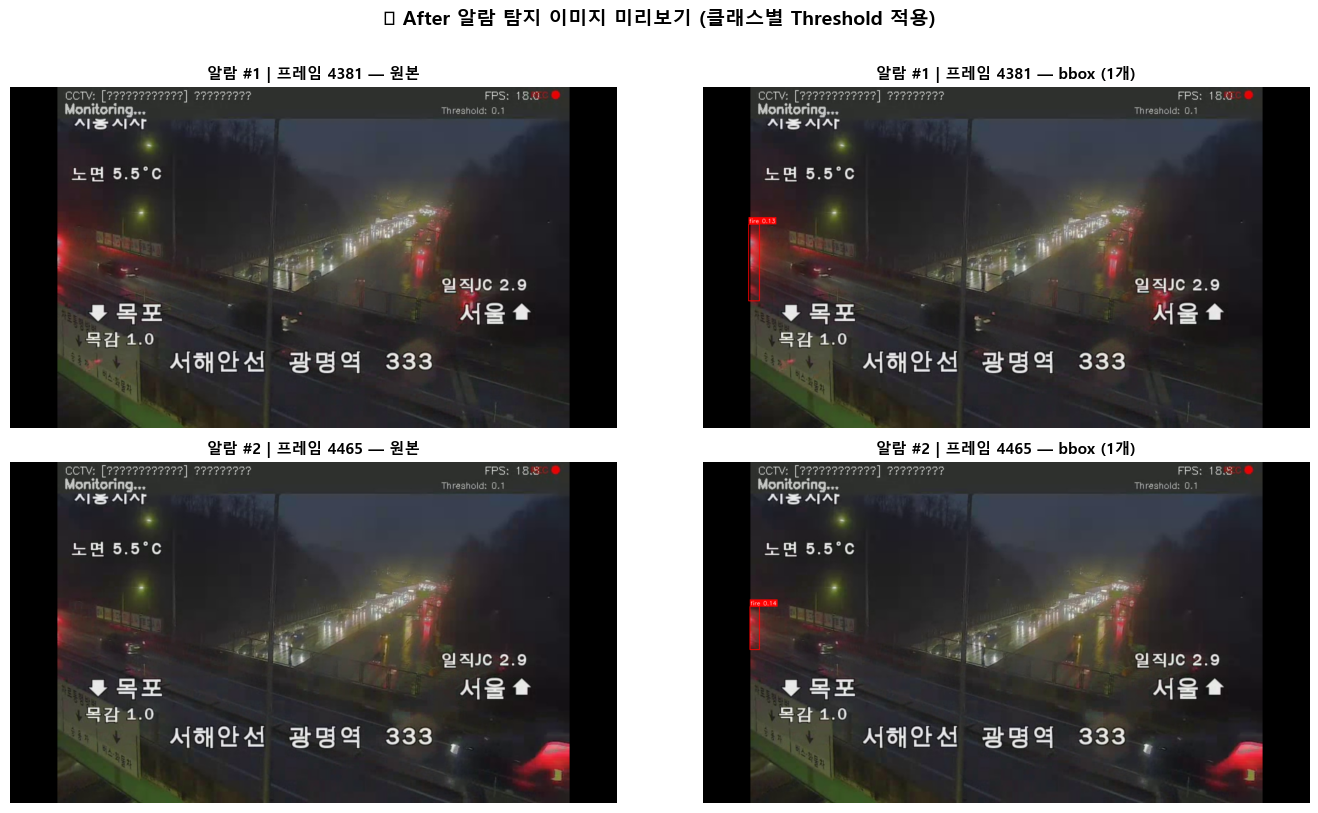


📸 미리보기 저장: N:\개인\이수빈\3.13_Mini_Project\results\class_threshold_test\after_detection_preview.png


In [10]:
# =============================================================================
# 셀 8-1: After 알람 발생 시점 — 원본 이미지 + bbox 이미지 저장
# =============================================================================

# ── 0. after_alarms가 비어 있으면 종료 ────────────────────────────
if not after_alarms:                                # 알람 없으면
    print("⚠️ after_alarms가 비어 있습니다. 저장할 알람이 없습니다.")
else:
    # ── 1. After 전용 저장 폴더 생성 ──────────────────────────────
    SAVE_AFTER_ORIG = SAVE_ROOT / "after_원본"       # After 원본 폴더
    SAVE_AFTER_BBOX = SAVE_ROOT / "after_bbox"       # After bbox 폴더
    SAVE_AFTER_ORIG.mkdir(parents=True, exist_ok=True)  # 폴더 생성
    SAVE_AFTER_BBOX.mkdir(parents=True, exist_ok=True)  # 폴더 생성
    print(f"📁 After 원본 저장 경로: {SAVE_AFTER_ORIG}")
    print(f"📁 After bbox 저장 경로: {SAVE_AFTER_BBOX}")

    # ── 2. 각 알람의 start_frame 목록 추출 ────────────────────────
    alarm_frames = []                                # (alarm_id, start_frame)
    for alarm in after_alarms:                       # 알람 순회
        aid = alarm["alarm_id"]                      # 알람 번호
        sf = alarm["start_frame"]                    # 시작 프레임
        alarm_frames.append((aid, sf))               # 리스트에 추가
    print(f"\n🔍 저장할 알람 수: {len(alarm_frames)}개")

    # ── 3. 영상 열기 ──────────────────────────────────────────────
    cap = cv2.VideoCapture(str(VIDEO_PATH))          # 영상 열기
    if not cap.isOpened():                           # 실패 시
        print(f"❌ 영상을 열 수 없습니다: {VIDEO_PATH}")
    else:
        # ── 4. 알람별 프레임 seek → 추론 → 저장 ──────────────────
        after_saved_count = 0                        # 저장 카운터
        preview_pairs = []                           # 미리보기용 리스트

        for aid, frame_idx in alarm_frames:          # 알람 하나씩
            # 해당 프레임으로 이동
            cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)  # 프레임 점프
            ret, frame = cap.read()                  # 프레임 읽기
            if not ret:                              # 실패 시
                print(f"   ⚠️ 알람 #{aid} 프레임 {frame_idx} 읽기 실패")
                continue                             # 다음으로

            # 원본 이미지 저장
            orig_name = f"after_alarm_{aid:04d}_frame{frame_idx}.jpg"
            cv2.imwrite(str(SAVE_AFTER_ORIG / orig_name), frame)

            # YOLO 추론
            results = model.predict(                 # 모델 예측
                source=frame,                        # 입력 프레임
                conf=CONF_THRESHOLD,                 # 0.10으로 다 받기
                device=DEVICE,                       # CPU
                verbose=False                        # 로그 숨김
            )

            # ★ 클래스별 Threshold 후처리 + bbox 그리기
            bbox_frame = frame.copy()                # 원본 복사
            boxes = results[0].boxes                 # bbox 목록
            det_count = 0                            # 후처리 통과 수

            for box in boxes:                        # bbox 순회
                cls_id = int(box.cls[0].cpu().numpy())    # 클래스 번호
                conf = float(box.conf[0].cpu().numpy())   # 신뢰도
                cls_name = class_names.get(cls_id, f"cls_{cls_id}")
                threshold = CLASS_THRESHOLDS.get(cls_id, CONF_THRESHOLD)

                if conf >= threshold:                # 후처리 통과
                    det_count += 1                   # 통과 카운터
                    x1, y1, x2, y2 = box.xyxy[0].cpu().numpy().astype(int)
                    color = COLOR_MAP.get(cls_name, DEFAULT_COLOR)
                    cv2.rectangle(bbox_frame, (x1,y1), (x2,y2), color, 2)
                    label = f"{cls_name} {conf:.2f}"
                    (tw, th), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.6, 1)
                    cv2.rectangle(bbox_frame, (x1,y1-th-8), (x1+tw+4,y1), color, -1)
                    cv2.putText(bbox_frame, label, (x1+2,y1-4),
                                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255,255,255), 1, cv2.LINE_AA)

            # bbox 이미지 저장
            bbox_name = f"after_alarm_{aid:04d}_frame{frame_idx}.jpg"
            cv2.imwrite(str(SAVE_AFTER_BBOX / bbox_name), bbox_frame)

            # 미리보기용 저장 (최대 6세트)
            if len(preview_pairs) < 6:               # 6개까지만
                preview_pairs.append((
                    cv2.cvtColor(frame, cv2.COLOR_BGR2RGB),      # 원본 RGB
                    cv2.cvtColor(bbox_frame, cv2.COLOR_BGR2RGB), # bbox RGB
                    aid, frame_idx, det_count        # 알람정보
                ))

            after_saved_count += 1                   # 저장 카운터 증가
            print(f"   ✅ 알람 #{aid:04d} | 프레임 {frame_idx} | "
                  f"탐지 {det_count}개 | 저장 완료")

        cap.release()                                # 영상 닫기
        print(f"\n{'=' * 60}")
        print(f"📊 After 이미지 저장 완료: 총 {after_saved_count}장")

        # ── 5. matplotlib 미리보기 ────────────────────────────────
        if preview_pairs:                            # 미리보기 있으면
            n_preview = len(preview_pairs)           # 개수
            fig, axes = plt.subplots(n_preview, 2,   # N행 2열
                                     figsize=(14, 4 * n_preview))
            if n_preview == 1:                       # 1행이면
                axes = axes.reshape(1, -1)           # 2D로 변환

            for row, (orig_rgb, bbox_rgb, aid, fidx, det_cnt) in enumerate(preview_pairs):
                axes[row, 0].imshow(orig_rgb)        # 원본 표시
                axes[row, 0].set_title(f"알람 #{aid} | 프레임 {fidx} — 원본",
                                       fontsize=11, fontweight="bold")
                axes[row, 0].axis("off")             # 축 숨김
                axes[row, 1].imshow(bbox_rgb)        # bbox 표시
                axes[row, 1].set_title(f"알람 #{aid} | 프레임 {fidx} — bbox ({det_cnt}개)",
                                       fontsize=11, fontweight="bold")
                axes[row, 1].axis("off")             # 축 숨김

            plt.suptitle("🟢 After 알람 탐지 이미지 미리보기 (클래스별 Threshold 적용)",
                         fontsize=14, fontweight="bold", y=1.01)
            plt.tight_layout()                       # 레이아웃 조정
            preview_path = SAVE_ROOT / "after_detection_preview.png"
            fig.savefig(str(preview_path), dpi=150, bbox_inches="tight", facecolor="white")
            plt.show()                               # 화면 표시
            print(f"\n📸 미리보기 저장: {preview_path}")
        else:                                        # 없으면
            print("⚠️ 미리보기할 이미지가 없습니다.")


In [11]:
# =============================================================================
# 셀 9: 결과 비교 + JSON 저장 (3단계 비교)
# =============================================================================

# ── 1단계: 단일 conf=0.10 기준 이벤트 수 (raw) ────────────────────────
raw_events = []                                        # raw 이벤트 목록
in_evt = False                                         # 이벤트 상태
for i, detected in enumerate(raw_frame_results):       # 후처리 전 결과 순회
    if detected and not in_evt:                        # 새 이벤트 시작
        in_evt = True                                  # 활성화
        time_sec = i / fps if fps > 0 else 0           # 시간 계산
        raw_events.append({"start_frame": i, "time_sec": round(time_sec, 2)})
    elif not detected:                                 # 탐지 안 되면
        in_evt = False                                 # 비활성화

# ── 2단계: 클래스별 Threshold 적용 후 이벤트 수 (filtered) ─────────────
filtered_events = []                                   # filtered 이벤트 목록
in_evt = False                                         # 이벤트 상태 리셋
for i, detected in enumerate(before_frame_results):    # 후처리 후 결과 순회
    if detected and not in_evt:                        # 새 이벤트 시작
        in_evt = True                                  # 활성화
        time_sec = i / fps if fps > 0 else 0           # 시간 계산
        filtered_events.append({"start_frame": i, "time_sec": round(time_sec, 2)})
    elif not detected:                                 # 탐지 안 되면
        in_evt = False                                 # 비활성화

# ── 3단계 수치 계산 ──────────────────────────────────────────────────
raw_count = len(raw_events)                            # 1단계 이벤트 수
filtered_count = len(filtered_events)                  # 2단계 이벤트 수
after_count = len(after_alarms)                        # 3단계 알람 수

# 감소율 계산
red_stage2 = (1 - filtered_count / raw_count) * 100 if raw_count > 0 else 0
red_stage3 = (1 - after_count / raw_count) * 100 if raw_count > 0 else 0
red_stage23 = (1 - after_count / filtered_count) * 100 if filtered_count > 0 else 0

# ── 결과 출력 ──────────────────────────────────────────────────────
print()
print("=" * 60)                                        # 구분선
print("  연속 프레임 필터 + 클래스별 Threshold 효과 검증 결과")
print("=" * 60)                                        # 구분선
print(f"  1단계 (단일 0.10, 필터 없음)   : {raw_count}회")
print(f"  2단계 (클래스별 Threshold)      : {filtered_count}회 (감소율 {red_stage2:.1f}%)")
print(f"  3단계 (연속 {CONSECUTIVE_FRAMES}프레임 필터)    : {after_count}회 (감소율 {red_stage3:.1f}%)")
print(f"  총 감소율 (1→3단계)            : {red_stage3:.1f}%")
print("=" * 60)                                        # 구분선

print(f"\n📋 상세:")
print(f"  총 프레임: {len(before_frame_results):,}")
print(f"  후처리 전 탐지 프레임: {raw_detect_count:,}")
print(f"  후처리 후 탐지 프레임: {filtered_detect_count:,}")
print(f"  smoke 제거 박스: {filtered_out_smoke:,}개")
print(f"  저장된 이미지: {saved_count}세트")

# ── JSON 저장 ──────────────────────────────────────────────────────
summary = {
    "test_info": {
        "model": "YOLOv8n_tuned",
        "conf_threshold": CONF_THRESHOLD,
        "fire_threshold": FIRE_THRESHOLD,
        "smoke_threshold": SMOKE_THRESHOLD,
        "consecutive_frames": CONSECUTIVE_FRAMES,
        "video": str(VIDEO_PATH.name),
        "total_frames": len(before_frame_results),
        "fps": fps
    },
    "stage1_raw": {
        "detection_frames": raw_detect_count,
        "events": raw_count
    },
    "stage2_class_threshold": {
        "detection_frames": filtered_detect_count,
        "events": filtered_count,
        "reduction_from_stage1": round(red_stage2, 1),
        "filtered_out_smoke_boxes": filtered_out_smoke,
        "fire_frames": total_fire,
        "smoke_frames": total_smoke,
        "both_frames": total_both
    },
    "stage3_temporal_filter": {
        "alarms": after_count,
        "reduction_from_stage1": round(red_stage3, 1),
        "reduction_from_stage2": round(red_stage23, 1),
        "fire_alarms": fire_events,
        "smoke_alarms": smoke_events
    },
    "saved_images": saved_count
}

json_path = SAVE_ROOT / "filter_summary.json"          # JSON 경로
with open(json_path, "w", encoding="utf-8") as f:      # 파일 열기
    json.dump(summary, f, indent=2, ensure_ascii=False) # JSON 저장
print(f"\n💾 요약 저장: {json_path}")



  연속 프레임 필터 + 클래스별 Threshold 효과 검증 결과
  1단계 (단일 0.10, 필터 없음)   : 66회
  2단계 (클래스별 Threshold)      : 47회 (감소율 28.8%)
  3단계 (연속 10프레임 필터)    : 2회 (감소율 97.0%)
  총 감소율 (1→3단계)            : 97.0%

📋 상세:
  총 프레임: 37,434
  후처리 전 탐지 프레임: 218
  후처리 후 탐지 프레임: 148
  smoke 제거 박스: 70개
  저장된 이미지: 47세트

💾 요약 저장: N:\개인\이수빈\3.13_Mini_Project\results\class_threshold_test\filter_summary.json


C:\Users\User\AppData\Local\Temp\ipykernel_10896\1472658522.py:60: UserWarning: Glyph 127916 (\N{CLAPPER BOARD}) missing from font(s) Malgun Gothic.
  plt.tight_layout()                                     # 레이아웃 조정
C:\Users\User\AppData\Local\Temp\ipykernel_10896\1472658522.py:60: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) Malgun Gothic.
  plt.tight_layout()                                     # 레이아웃 조정
C:\Users\User\AppData\Local\Temp\ipykernel_10896\1472658522.py:60: UserWarning: Glyph 128168 (\N{DASH SYMBOL}) missing from font(s) Malgun Gothic.
  plt.tight_layout()                                     # 레이아웃 조정
C:\Users\User\AppData\Local\Temp\ipykernel_10896\1472658522.py:60: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) Malgun Gothic.
  plt.tight_layout()                                     # 레이아웃 조정
C:\Users\User\AppData\Local\Temp\ipykernel_10896\1472658522.py:60: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) Malgu

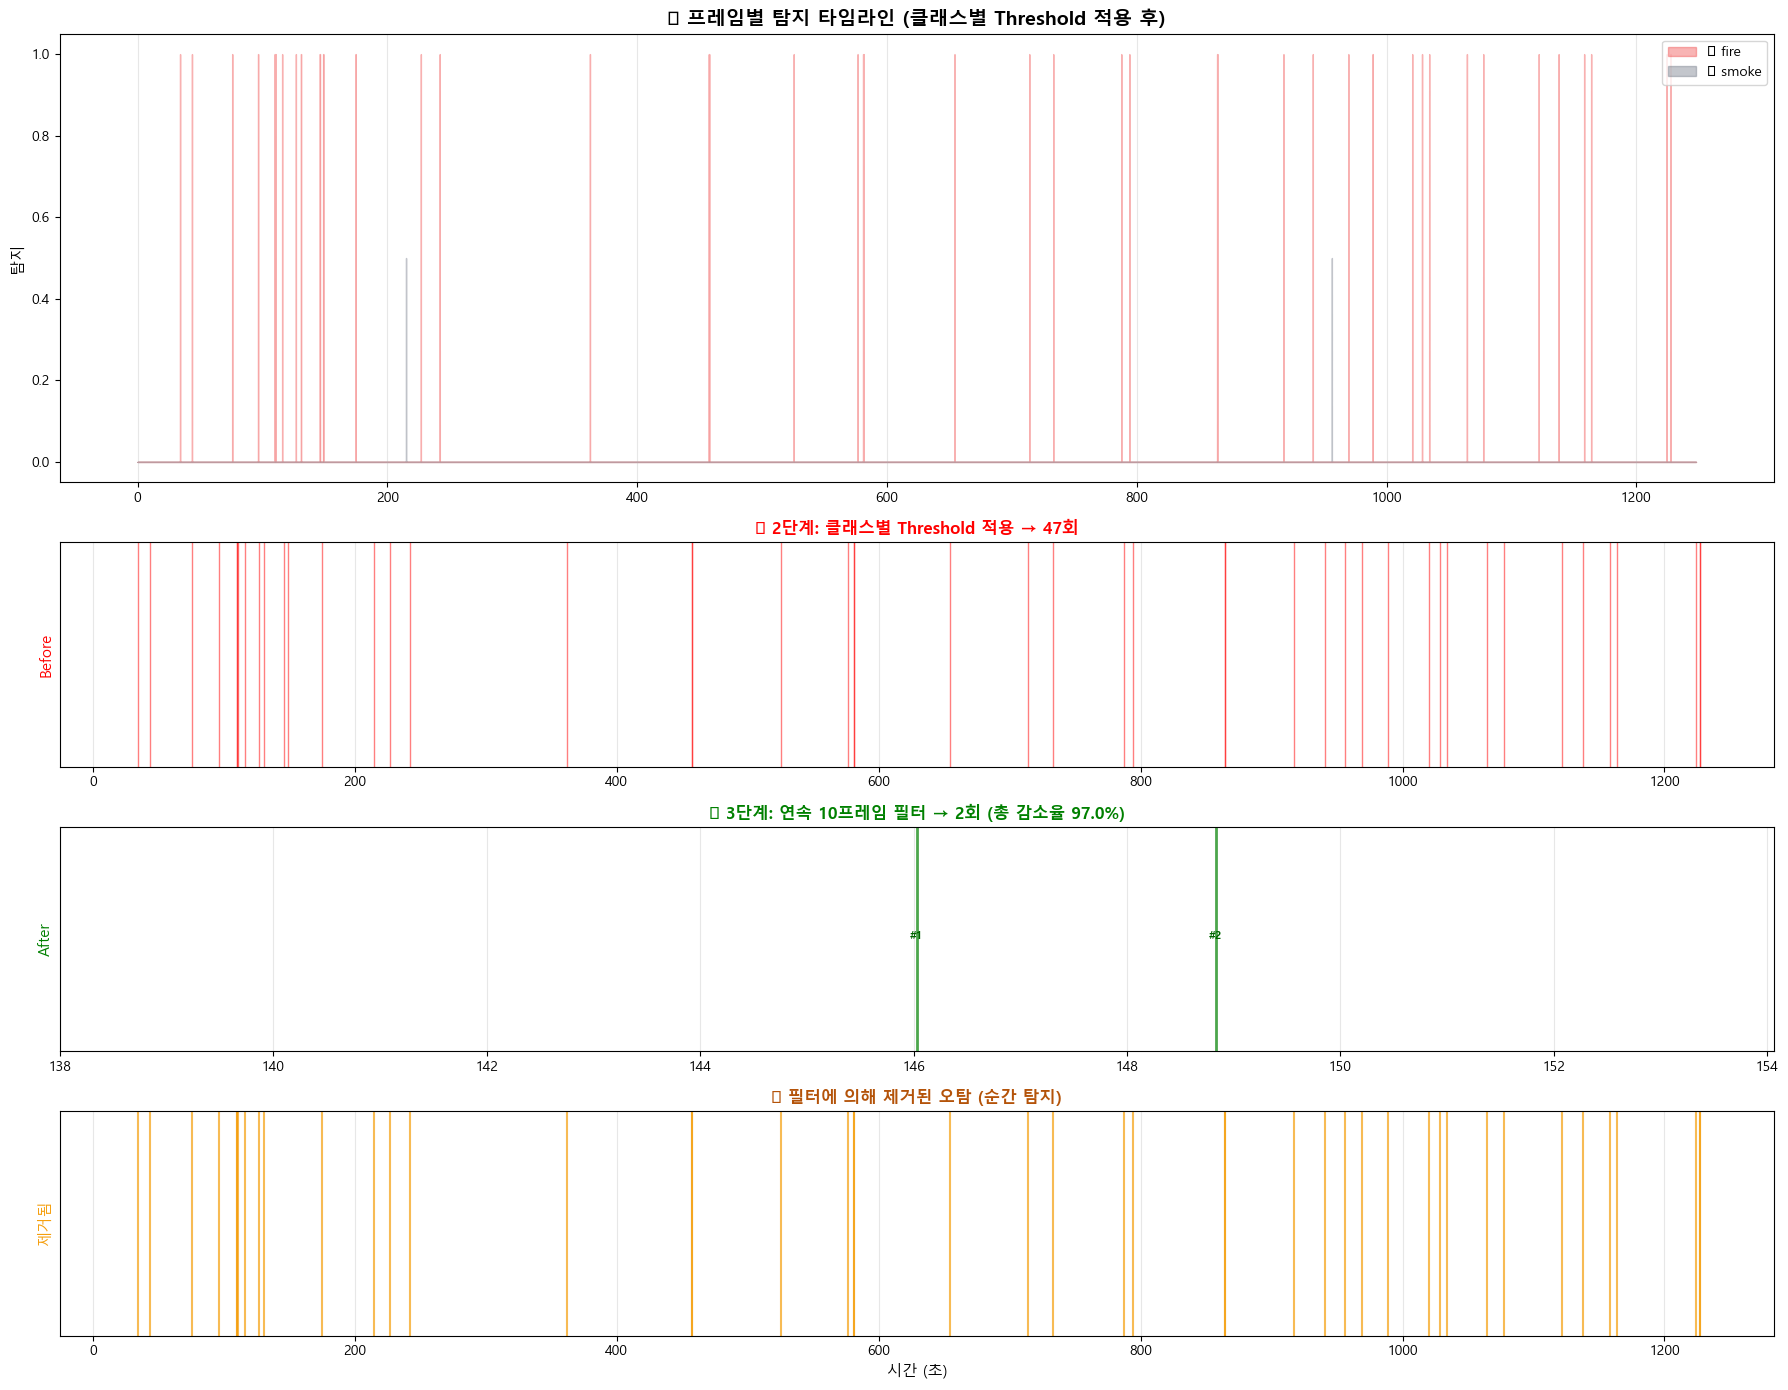


💾 저장: N:\개인\이수빈\3.13_Mini_Project\results\class_threshold_test\temporal_filter_timeline.png


In [12]:
# =============================================================================
# 셀 10: 타임라인 시각화
# =============================================================================

fig, axes = plt.subplots(4, 1, figsize=(18, 14),
                         gridspec_kw={"height_ratios": [2, 1, 1, 1]})

time_axis = np.arange(len(before_frame_results)) / fps  # 시간축 (초)

# ─── 1행: 전체 탐지 타임라인 (smoke/fire 색상 구분) ───
ax1 = axes[0]                                          # 첫 번째 축
fire_vals = []                                         # fire 시각화용
smoke_vals = []                                        # smoke 시각화용
for classes in before_frame_classes:                    # 클래스 목록 순회
    fire_vals.append(1 if "fire" in classes else 0)    # fire 있으면 1
    smoke_vals.append(0.5 if "smoke" in classes else 0) # smoke 있으면 0.5

ax1.fill_between(time_axis, fire_vals, alpha=0.4, color="#ef4444", label="🔥 fire")
ax1.fill_between(time_axis, smoke_vals, alpha=0.4, color="#6b7280", label="💨 smoke")
ax1.set_ylabel("탐지", fontsize=11)                    # y축 레이블
ax1.set_title("🎬 프레임별 탐지 타임라인 (클래스별 Threshold 적용 후)", fontsize=14, fontweight="bold")
ax1.legend(loc="upper right", fontsize=10)             # 범례
ax1.grid(axis="x", alpha=0.3)                         # 격자

# ─── 2행: Before (클래스별 Threshold 적용, 필터 없음) ───
ax2 = axes[1]                                          # 두 번째 축
for event in filtered_events:                          # 2단계 이벤트 순회
    ax2.axvline(x=event["time_sec"], color="red", alpha=0.5, linewidth=1)
ax2.set_ylabel("Before", fontsize=11, color="red")     # y축 레이블
ax2.set_title(f"🔴 2단계: 클래스별 Threshold 적용 → {filtered_count}회",
              fontsize=12, fontweight="bold", color="red")
ax2.set_yticks([])                                     # y축 눈금 숨김
ax2.grid(axis="x", alpha=0.3)                         # 격자

# ─── 3행: After (연속 프레임 필터 적용) ───
ax3 = axes[2]                                          # 세 번째 축
for alarm in after_alarms:                             # 알람 순회
    ax3.axvline(x=alarm["time_sec"], color="green", alpha=0.7, linewidth=2)
    ax3.annotate(f'#{alarm["alarm_id"]}', xy=(alarm["time_sec"], 0.5),
                fontsize=8, ha="center", color="darkgreen", fontweight="bold")
ax3.set_ylabel("After", fontsize=11, color="green")    # y축 레이블
ax3.set_title(f"🟢 3단계: 연속 {CONSECUTIVE_FRAMES}프레임 필터 → {after_count}회 (총 감소율 {red_stage3:.1f}%)",
              fontsize=12, fontweight="bold", color="green")
ax3.set_yticks([])                                     # y축 눈금 숨김
ax3.grid(axis="x", alpha=0.3)                         # 격자

# ─── 4행: 제거된 오탐 ───
ax4 = axes[3]                                          # 네 번째 축
after_times = set(a["time_sec"] for a in after_alarms) # After 시간 집합
for event in filtered_events:                          # 2단계 이벤트 순회
    matched = any(abs(event["time_sec"] - at) < 10 for at in after_times)
    if not matched:                                    # After에 없으면 = 제거된 오탐
        ax4.axvline(x=event["time_sec"], color="#f59e0b", alpha=0.7, linewidth=1.5)
ax4.set_ylabel("제거됨", fontsize=11, color="#f59e0b")  # y축 레이블
ax4.set_title("🟡 필터에 의해 제거된 오탐 (순간 탐지)", fontsize=12, fontweight="bold", color="#b45309")
ax4.set_yticks([])                                     # y축 눈금 숨김
ax4.set_xlabel("시간 (초)", fontsize=11)               # x축 레이블
ax4.grid(axis="x", alpha=0.3)                         # 격자

plt.tight_layout()                                     # 레이아웃 조정
plt.savefig(str(SAVE_ROOT / "temporal_filter_timeline.png"),
            dpi=150, bbox_inches="tight", facecolor="white")
plt.show()                                             # 화면 표시
print(f"\n💾 저장: {SAVE_ROOT / 'temporal_filter_timeline.png'}")


C:\Users\User\AppData\Local\Temp\ipykernel_10896\1971009535.py:51: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) Malgun Gothic.
  plt.tight_layout()                                     # 레이아웃 조정
C:\Users\User\AppData\Local\Temp\ipykernel_10896\1971009535.py:52: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) Malgun Gothic.
  plt.savefig(str(SAVE_ROOT / "three_stage_comparison.png"),
c:\Users\User\.conda\envs\DL\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


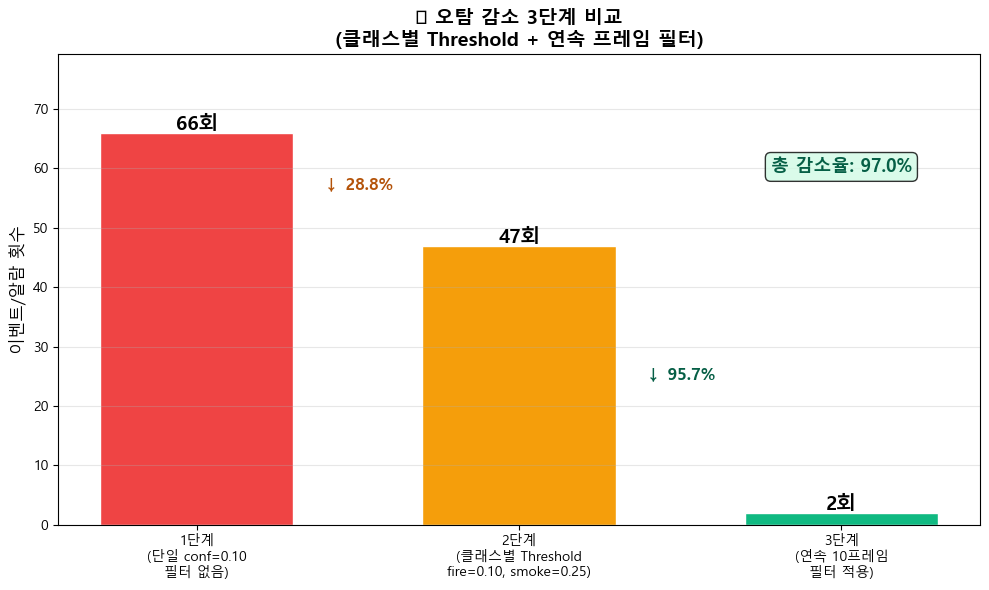


💾 저장: N:\개인\이수빈\3.13_Mini_Project\results\class_threshold_test\three_stage_comparison.png


In [13]:
# =============================================================================
# 셀 10-1: ★ 3단계 비교 막대 그래프 (신규)
# =============================================================================

fig, ax = plt.subplots(figsize=(10, 6))                # 그래프 생성

# 3단계 데이터
stages = ["1단계\n(단일 conf=0.10\n필터 없음)",
          "2단계\n(클래스별 Threshold\nfire=0.10, smoke=0.25)",
          "3단계\n(연속 10프레임\n필터 적용)"]
values = [raw_count, filtered_count, after_count]       # 각 단계 이벤트 수
colors = ["#ef4444", "#f59e0b", "#10b981"]              # 빨강, 주황, 초록

# 막대 그래프 그리기
bars = ax.bar(range(3), values, color=colors,           # 막대 생성
              edgecolor="white", width=0.6)             # 테두리 흰색

# 막대 위에 숫자 표시
for i, (bar, val) in enumerate(zip(bars, values)):     # 막대 순회
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f"{val}회", ha="center", fontsize=14, fontweight="bold")

# 단계 간 감소율 화살표 텍스트
if raw_count > 0 and filtered_count < raw_count:       # 1→2단계 감소 있으면
    mid_y = (raw_count + filtered_count) / 2           # 중간 높이
    ax.annotate(f"↓ {red_stage2:.1f}%",                # 감소율 텍스트
                xy=(0.5, mid_y), fontsize=12, ha="center",
                color="#b45309", fontweight="bold")

if filtered_count > 0 and after_count < filtered_count: # 2→3단계 감소 있으면
    mid_y = (filtered_count + after_count) / 2         # 중간 높이
    ax.annotate(f"↓ {red_stage23:.1f}%",               # 감소율 텍스트
                xy=(1.5, mid_y), fontsize=12, ha="center",
                color="#065f46", fontweight="bold")

# 총 감소율 표시
ax.text(2, max(values) * 0.9,                          # 오른쪽 상단
        f"총 감소율: {red_stage3:.1f}%",               # 총 감소율
        fontsize=13, ha="center", color="#065f46",
        fontweight="bold", bbox=dict(boxstyle="round,pad=0.3",
                                     facecolor="#d1fae5", alpha=0.8))

ax.set_xticks(range(3))                                # x축 눈금 위치
ax.set_xticklabels(stages, fontsize=10)                # x축 레이블
ax.set_ylabel("이벤트/알람 횟수", fontsize=12)          # y축 레이블
ax.set_title("🔥 오탐 감소 3단계 비교\n(클래스별 Threshold + 연속 프레임 필터)",
             fontsize=14, fontweight="bold")
ax.grid(axis="y", alpha=0.3)                           # 격자
ax.set_ylim(0, max(values) * 1.2)                     # y축 범위

plt.tight_layout()                                     # 레이아웃 조정
plt.savefig(str(SAVE_ROOT / "three_stage_comparison.png"),
            dpi=150, bbox_inches="tight", facecolor="white")
plt.show()                                             # 화면 표시
print(f"\n💾 저장: {SAVE_ROOT / 'three_stage_comparison.png'}")


🔬 다양한 연속 프레임 수별 비교
  연속  1프레임 | 알람  47회 | 감소율   0.0% | 지연 0.03초
  연속  3프레임 | 알람  14회 | 감소율  70.2% | 지연 0.10초
  연속  5프레임 | 알람   7회 | 감소율  85.1% | 지연 0.17초
  연속  7프레임 | 알람   4회 | 감소율  91.5% | 지연 0.23초
  연속 10프레임 | 알람   2회 | 감소율  95.7% | 지연 0.33초 ★ 현재
  연속 15프레임 | 알람   0회 | 감소율 100.0% | 지연 0.50초
  연속 30프레임 | 알람   0회 | 감소율 100.0% | 지연 1.00초


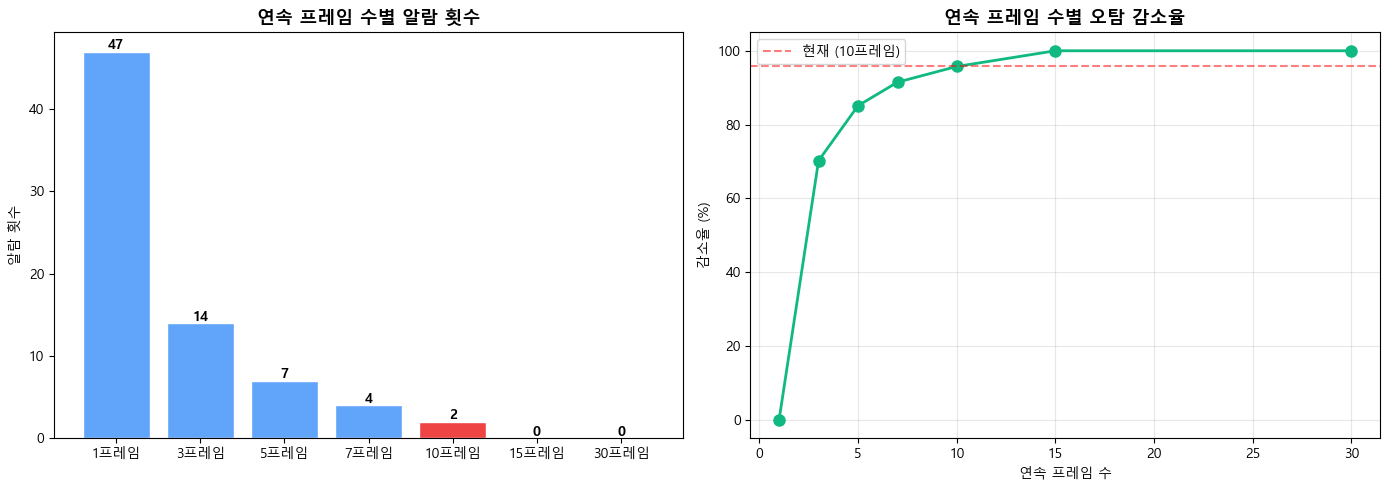


💾 저장: N:\개인\이수빈\3.13_Mini_Project\results\class_threshold_test\frame_threshold_comparison.png


In [14]:
# =============================================================================
# 셀 11: 다양한 연속 프레임 수별 비교
# =============================================================================

print("=" * 60)                                        # 구분선
print("🔬 다양한 연속 프레임 수별 비교")                # 제목
print("=" * 60)                                        # 구분선

test_thresholds = [1, 3, 5, 7, 10, 15, 30]             # 비교할 프레임 수
comparison_results = []                                 # 결과 저장

for n_frames in test_thresholds:                        # 프레임 수 순회
    count = 0                                           # 연속 카운터
    active = False                                      # 알람 상태
    alarm_count = 0                                     # 알람 수

    for detected in before_frame_results:               # 후처리 후 결과 순회
        if detected:                                    # 탐지됐으면
            count += 1                                  # 카운터 증가
        else:                                           # 안 됐으면
            count = 0                                   # 리셋
            active = False                              # 비활성화
        if count >= n_frames and not active:            # 기준 도달
            active = True                               # 활성화
            alarm_count += 1                            # 알람 카운터

    red = (1 - alarm_count / filtered_count) * 100 if filtered_count > 0 else 0
    delay = n_frames / fps if fps > 0 else 0            # 지연 시간
    comparison_results.append({"frames": n_frames, "alarms": alarm_count,
                               "reduction": red, "delay": delay})

    marker = " ★ 현재" if n_frames == CONSECUTIVE_FRAMES else ""
    print(f"  연속 {n_frames:>2}프레임 | 알람 {alarm_count:>3}회 | "
          f"감소율 {red:>5.1f}% | 지연 {delay:.2f}초{marker}")

# 그래프
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))  # 2열 그래프

frames_list = [r["frames"] for r in comparison_results] # 프레임 수 리스트
alarms_list = [r["alarms"] for r in comparison_results] # 알람 수 리스트
colors = ["#ef4444" if f == CONSECUTIVE_FRAMES else "#60a5fa" for f in frames_list]

ax1.bar(range(len(frames_list)), alarms_list, color=colors, edgecolor="white")
ax1.set_xticks(range(len(frames_list)))                 # x축 눈금
ax1.set_xticklabels([f"{f}프레임" for f in frames_list]) # x축 레이블
ax1.set_ylabel("알람 횟수")                             # y축 레이블
ax1.set_title("연속 프레임 수별 알람 횟수", fontsize=13, fontweight="bold")
for i, v in enumerate(alarms_list):                     # 막대 위 숫자
    ax1.text(i, v + 0.3, str(v), ha="center", fontweight="bold")

reductions = [r["reduction"] for r in comparison_results] # 감소율 리스트
ax2.plot(frames_list, reductions, marker="o", color="#10b981", linewidth=2, markersize=8)
current_idx = frames_list.index(CONSECUTIVE_FRAMES)     # 현재 설정 인덱스
ax2.axhline(y=reductions[current_idx], color="red", linestyle="--", alpha=0.5,
            label=f"현재 ({CONSECUTIVE_FRAMES}프레임)")
ax2.set_xlabel("연속 프레임 수")                        # x축 레이블
ax2.set_ylabel("감소율 (%)")                            # y축 레이블
ax2.set_title("연속 프레임 수별 오탐 감소율", fontsize=13, fontweight="bold")
ax2.legend()                                            # 범례
ax2.grid(alpha=0.3)                                     # 격자

plt.tight_layout()                                      # 레이아웃 조정
plt.savefig(str(SAVE_ROOT / "frame_threshold_comparison.png"),
            dpi=150, bbox_inches="tight", facecolor="white")
plt.show()                                              # 화면 표시
print(f"\n💾 저장: {SAVE_ROOT / 'frame_threshold_comparison.png'}")


## 🏁 최종 결론

### 산출물 목록
| 파일/폴더 | 설명 |
|-----------|------|
| `원본/` | 탐지 이벤트 시작 시점의 원본 이미지 |
| `bbox/` | 같은 시점의 바운딩박스 이미지 (클래스별 Threshold 적용) |
| `after_원본/` | After 알람 시점의 원본 이미지 |
| `after_bbox/` | After 알람 시점의 bbox 이미지 |
| `before_detections.csv` | Before 전체 탐지 기록 |
| `after_alarms.csv` | After 알람 기록 |
| `filter_summary.json` | 3단계 비교 요약 |
| `detection_preview.png` | 원본+bbox 미리보기 (처음 8세트) |
| `after_detection_preview.png` | After 알람 미리보기 |
| `class_distribution.png` | smoke/fire 파이 차트 |
| `temporal_filter_timeline.png` | 4행 타임라인 |
| `three_stage_comparison.png` | 3단계 비교 막대 그래프 |
| `frame_threshold_comparison.png` | 프레임 수별 비교 |

### 설정 변경 방법
셀 2에서 아래 값만 바꾸고 셀 2부터 다시 실행:
```python
FIRE_THRESHOLD = 0.10      # fire 후처리 기준
SMOKE_THRESHOLD = 0.25     # smoke 후처리 기준
CONSECUTIVE_FRAMES = 10    # 연속 프레임 기준
```
